<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Construcción de Dataset — Contexto Vecinal 3×3 (v5)</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellín, Abril de 2026</div>

  <div style="height:0.1rem;"></div>

</div>

Este *Notebook* extiende la versión v4 añadiendo **contexto vecinal 3×3 por banda**: para cada píxel y cada banda espectral se calculan la **media** y la **desviación estándar** de sus 8 vecinos inmediatos que se encuentran **dentro de la máscara de la hoja**, capturando así la heterogeneidad local de reflectancia sin abandonar el nivel de píxel.

**Diferencias respecto a v4:**
- Se añaden columnas `mean_<nm>` y `std_<nm>` para cada longitud de onda.
- Los píxeles de fondo nunca participan como vecinos (enmascaramiento con `NaN` antes del filtrado).
- Los píxeles en el borde de la hoja con pocos vecinos válidos obtienen estadísticas sobre los vecinos disponibles; los píxeles aislados (sin ningún vecino válido) heredan su propio valor como media y std = 0.
- El esquema de salida pasa de 16 a **36 columnas** por fila.

### Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import os
from scipy.io import loadmat
import cv2
import pandas as pd
import time

# 1. Exploración de los datos

Identificar la estructura del cubo espectral original, las máscaras y la nomenclatura de archivos. En esta sección se navega por los directorios, se inspeccionan bandas individuales y se documenta la semántica de tratamientos y genotipos.

## 1.1 Exploración de imágenes individuales

Se toman muestras puntuales tanto de fríjol como de maíz para validar dimensiones, canales disponibles y consistencia de las máscaras. Esto sirve como referencia visual para el resto del flujo.

Se usa una pareja `REF`/`CLASS` de fríjol como ejemplo ancla. La imagen contiene el cubo multiespectral (`R`) y la máscara asociada (`class_map`) que codifica los genotipos visibles.

In [2]:
base_image_path = "data/mat/frijol/Nov_3_2021/REF__0000_T2R1.mat"
base_image_map_path = "data/mat/frijol/Nov_3_2021/CLASS__0000_T2R1.mat"

**Imágenes de maíz**

Para contrastar el comportamiento espectral entre cultivos, también se seleccionan dos archivos de maíz: uno con un solo genotipo por repetición (1G) y otro con dos genotipos (2G). Esto permite validar que la lógica posterior soporte ambas configuraciones.

In [3]:
base_image_path_corn_1G = "data/mat/maiz/Oct_27_2022/REF__0001_T1R1G1.mat" # Un genotipo
base_image_map_path_corn_1G = "data/mat/maiz/Oct_27_2022/CLASS__0001_T1R1G1.mat" # Un genotipos
base_image_path_corn_2G = "data/mat/maiz/jun_23_2022/REF__0002_T1R1G10G4.mat" # Dos genotipo
base_image_map_path_corn_2G = "data/mat/maiz/jun_23_2022/CLASS__0002_T1R1G10G4.mat" # Dos genotipos

**Leer imagen multiespectral**

Se miden las dimensiones (alto × ancho × banda) y se verifica el tipo de dato.

In [4]:
# Cargar el archivo multiespectral (R) y la máscara de clases asociada
mat_data = loadmat(base_image_path)
mat_class_data = loadmat(base_image_map_path)

# Acceder a la imagen
imagen_base = mat_data['R']
imagen_base_mask = mat_class_data['class_map']

print(f"Archivo: '{base_image_path}'")
print(f"Dimensiones del array: {imagen_base.shape}") # alto, ancho, bandas
print(f"Tipo de dato del array: {imagen_base.dtype}")

Archivo: 'data/mat/frijol/Nov_3_2021/REF__0000_T2R1.mat'
Dimensiones del array: (960, 1280, 10)
Tipo de dato del array: float64


Imágenes base de maíz

In [5]:
# Cargar cubos y máscaras para los casos de maíz (1 genotipo y 2 genotipos)
mat_data_corn_1G = loadmat(base_image_path_corn_1G)
mat_class_data_corn_1G = loadmat(base_image_map_path_corn_1G)
mat_data_corn_2G = loadmat(base_image_path_corn_2G)
mat_class_data_corn_2G = loadmat(base_image_map_path_corn_2G)

# Acceder a la imagen
imagen_base_corn_1G = mat_data_corn_1G['R']
imagen_base_mask_corn_1G = mat_class_data_corn_1G['class_map']
imagen_base_corn_2G = mat_data_corn_2G['R']
imagen_base_mask_corn_2G = mat_class_data_corn_2G['class_map']

**Mostrar imagen para una banda y la máscara de la imagen**

Visualizar una banda del cubo junto con su `class_map` para verificar la segmentación de las hojas y entender la distribución espacial de los genotipos etiquetados.

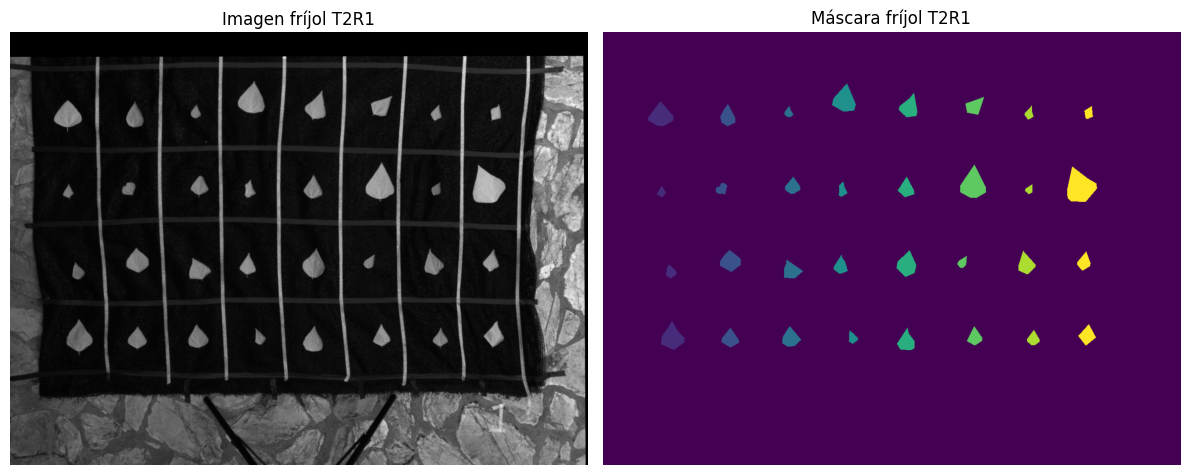

In [6]:
# Visualizar una banda representativa junto con su máscara
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(imagen_base[:,:,8], cmap='gray')
axes[0].set_title('Imagen fríjol T2R1')
axes[0].axis('off')

axes[1].imshow(imagen_base_mask)
axes[1].set_title('Máscara fríjol T2R1')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 1.1.1 Indexación de las bandas

**Información de las bandas**

<img src="assets/info_bandas.png" width="700">

**Información de los canales**

<img src="assets/info_canales.png" width="900">

**Mapear bandas con canales**

In [ ]:
red_mx = [2,4,6,10,8]
red_mx_labels = ["475","560","668","717","842"]
blue_mx = [1,3,5,7,9]
blue_mx_labels = ["444","561","650","705","740"]
red_mx_index = [x - 1 for x in red_mx]
blue_mx_index = [x - 1 for x in blue_mx]

print("Red-MX Índices:", red_mx_index)
print("Blue-MX Índices:", blue_mx_index)

### 1.1.2 Visualizar todas las bandas de una imagen

In [ ]:
# Generar matriz comparativa para todas las bandas Red-MX y Blue-MX
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, band_idx in enumerate(red_mx_index):
    ax = axes[0, i]
    ax.imshow(imagen_base[:,:,band_idx], cmap='gray')
    ax.set_title(f'Red-MX Banda {i+1}: {red_mx_labels[i]} nm')
    ax.axis('off')

for i, band_idx in enumerate(blue_mx_index):
        ax = axes[1, i] 
        ax.imshow(imagen_base[:,:,band_idx], cmap='gray')
        ax.set_title(f'Blue-MX Banda {i+1}: {blue_mx_labels[i]} nm')
        ax.axis('off')

plt.tight_layout()
plt.show()

### 1.1.3 Composición imagen RGB

Se construyen composiciones pseudo-RGB para tener una referencia visual rápida del cultivo y validar alineación de las bandas.

In [ ]:
print(f"Tamaño de la imagen base de ejemplo: {imagen_base.shape}")

**Normalización Min-Max por banda de una imagen**

Cada banda se escala de forma independiente a $[0,1]$ haciendo comparables las firmas espectrales y mejorando la estabilidad numérica.

In [ ]:
def normalize_image(image):
    """Normaliza cada banda del cubo a [0,1] mediante min-max."""
    imagen_norm = np.empty_like(image, dtype=np.float32)

    for i in range(image.shape[2]):
        band = image[:,:,i]
        band_min = band.min()
        band_max = band.max()
        imagen_norm[:,:,i] = (band - band_min) / (band_max - band_min + 1e-6)  # Evita división por cero

    return imagen_norm

In [ ]:
# Normalizar imagen base
imagen_norm = normalize_image(imagen_base)

In [ ]:
# Composición RGB usando red_mx_index
r_red = imagen_norm[:, :, red_mx_index[2]]
g_red = imagen_norm[:, :, red_mx_index[1]]
b_red = imagen_norm[:, :, red_mx_index[0]]
rgb_red = np.stack([r_red, g_red, b_red], axis=-1)

# Composición RGB usando blue_mx_index
r_blue = imagen_norm[:, :, blue_mx_index[2]]
g_blue = imagen_norm[:, :, blue_mx_index[1]]
b_blue = imagen_norm[:, :, blue_mx_index[0]]
rgb_blue = np.stack([r_blue, g_blue, b_blue], axis=-1)

fig, axs = plt.subplots(1, 2, figsize=(16, 8))
axs[0].imshow(rgb_red)
axs[0].set_title("Composición RGB (red_mx_index)")
axs[0].axis('off')

axs[1].imshow(rgb_blue)
axs[1].set_title("Composición RGB (blue_mx_index)")
axs[1].axis('off')

plt.tight_layout()
plt.show()

## 1.2 Exploración conjunto de datos

El siguiente bloque resume la estructura global: carpetas por cultivo/fecha, cantidades por tratamiento y variación en los genotipos capturados.

**MAÍZ:**
- T: Tratamiento
- G: Genotipo (filas de la matriz de hojas)
- R : Muestra

**Etiquetas:** Estrés nutricional - Nitrógeno
- N1 (25% del requerimiento total de nitrógeno del cultivo) 
- N2 (50% nitrogeno)
- N3 (75% nitrogeno)
- N4 (100% nitrogeno)

---

**FRÍJOL:**
- T: Tratamiento
- R : Muestra
- Cada imagen tiene 8 genotipos equivalente a las columnas de la matriz de hojas

**Etiquetas:** Estrés nutricional - Fósforo
- F1 (25% del requerimeinto total de fósforo del cultivo)
- F2 (50% fósforo)
- F3 (75% fósforo)
- F4 (100% fósforo)

Estas convenciones se reutilizan más adelante para construir el nombre de cada registro en el CSV final.

### 1.2.1 Distribución de tratamiento y genotipo

Se cuantifica cuántas imágenes hay por tratamiento y combinación de genotipos.

#### 1.2.1.1 Maíz

In [ ]:
maiz_dir = "data/mat/maiz"

maiz = defaultdict(lambda: defaultdict(list))

file_pattern = re.compile(r"^.*?(T\d+)(?:R\d+)?((?:G\d+)+)\.mat$", re.IGNORECASE)

# Recorrer subdirectorios y agrupar rutas REF por tratamiento y combinación de genotipos
for root, _, files in os.walk(maiz_dir):
    for fname in files:
        nombre_normalizado = fname.lower()
        if nombre_normalizado.endswith(".mat") and not nombre_normalizado.startswith("classmap"):
            if not nombre_normalizado.startswith("ref"):
                continue

            match = file_pattern.match(fname)
            if match:
                tratamiento_key = match.group(1)
                genotipo_key_completo = match.group(2)

                ruta_completa_archivo = os.path.join(root, fname)
                maiz[tratamiento_key][genotipo_key_completo].append(ruta_completa_archivo)

In [ ]:
print("Total de muestras por Tratamiento/Genotipo imágenes de maíz:")
total_archivos_general = 0

for tratamiento, genotipos_data in sorted(maiz.items()):
    print(f"Tratamiento {tratamiento}:")
    total_por_tratamiento = 0

    for genotipo, archivos in sorted(genotipos_data.items()):
        num_muestras = len(archivos)
        print(f"  - {genotipo}: {num_muestras} muestras")
        total_por_tratamiento += num_muestras
    print(f"  Total para {tratamiento}: {total_por_tratamiento} muestras\n")
    total_archivos_general += total_por_tratamiento

print(f"Total general de archivos procesados: {total_archivos_general}")

#### 1.2.1.2 Fríjol

In [ ]:
frijol_dir = "data/mat/frijol"

frijol = defaultdict(list)

treatment_pattern = re.compile(r"_(T\d+)")

# Recorrer subdirectorios y contar solo archivos REF por tratamiento
for root, _, files in os.walk(frijol_dir):
    for fname in files:
        nombre_normalizado = fname.lower()
        if not nombre_normalizado.endswith(".mat"):
            continue
        if nombre_normalizado.startswith("classmap"):
            continue
        if not nombre_normalizado.startswith("ref"):
            continue

        match = treatment_pattern.search(fname)
        if match:
            tratamiento_key = match.group(1)
            ruta_completa_archivo = os.path.join(root, fname)
            frijol[tratamiento_key].append(ruta_completa_archivo)

In [ ]:
print("\nTotal de muestras por tratamiento imágenes de Fríjol:")
for tratamiento, archivos in sorted(frijol.items()):
    print(f"{tratamiento}: {len(archivos)} muestras")

### 1.2.2 Visualización de las clases

In [ ]:
# Función para cargar imagen desde .mat
def cargar_imagen_mat(filepath):
    """Carga la máscara `class_map` almacenada en un archivo .mat."""
    mat_class_data = loadmat(filepath)

    # Acceder a la imagen
    mask = mat_class_data['class_map']

    return mask

In [ ]:
ruta_principal = "data/mat"

for subcarpeta in os.listdir(ruta_principal):
    ruta_sub = os.path.join(ruta_principal, subcarpeta)
    if not os.path.isdir(ruta_sub):
        continue

    for fecha in os.listdir(ruta_sub):
        ruta_fecha = os.path.join(ruta_sub, fecha)
        if not os.path.isdir(ruta_fecha):
            continue
        
        # Cargar imágenes .mat
        archivos = [f for f in os.listdir(ruta_fecha) if f.startswith("CLASS__") and f.endswith(".mat")]
        if not archivos:
            continue
        
        n = len(archivos)
        cols = int(np.ceil(np.sqrt(n)))
        rows = int(np.ceil(n / cols))
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
        axes = axes.flatten() if n > 1 else [axes]
        
        # Mostrar imagen por cultivo y genotipos
        for i, archivo in enumerate(archivos):
            filepath = os.path.join(ruta_fecha, archivo)
            try:
                img = cargar_imagen_mat(filepath)
                axes[i].imshow(img)
                nombre = os.path.splitext(archivo)[0]  # quitar .mat
                axes[i].set_title(nombre, fontsize=8)
                axes[i].axis("off")
            except Exception as e:
                print(f"Error cargando {archivo}: {e}")
        
        for j in range(i+1, len(axes)):
            axes[j].axis("off")
        
        fig.suptitle(subcarpeta, fontsize=14) 
        plt.tight_layout()
        plt.show()

### 1.2.3 Definición de las clases de la máscara

**Ejemplo de genotipos (clases) en la máscara de fríjol**

Las máscaras codifican genotipos mediante números enteros.

In [ ]:
beans_genotype_classes = np.unique(imagen_base_mask)
Corn_1G_classes = np.unique(imagen_base_mask_corn_1G)
corn_2G_classes = np.unique(imagen_base_mask_corn_2G)
print("Clases únicas en la máscara base (Genotipo - Fríjol):", np.unique(beans_genotype_classes))
print("Clases únicas en la máscara base (Un genotipo - Maíz):", np.unique(Corn_1G_classes))
print("Clases únicas en la máscara base (Dos genotipo - Maíz):", np.unique(corn_2G_classes))

# 2. Preprocesamiento de una imagen

Con base en la exploración previa se detallan los pasos de preprocesamiento para una imagen: elección de una banda, segmentación de hojas, perfiles de intensidad y obtención de firmas espectrales.

In [ ]:
# Tomar una de las bandas imagen de fríjol como ejemplo
original_image_array = imagen_norm[:,:,6]

print(f"Tamaño de la imagen de una de las bandas - Fríjol: {original_image_array.shape}")

## 2.1 Segmentar hojas

Se construye una máscara binaria a partir del `class_map` y se aplica sobre la banda seleccionada para aislar únicamente las hojas, eliminando fondo y ruido.

In [ ]:
# Binarización de la máscara imagen base fríjol
_, image_mask_binary = cv2.threshold(imagen_base_mask, 0, 255, cv2.THRESH_BINARY)

# Aplicar máscara a imagen original para segmentar hojas
result = cv2.bitwise_and(original_image_array, original_image_array, mask=image_mask_binary)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(original_image_array, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Máscara Original')
plt.imshow(imagen_base_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Máscara Binaria (Procesada)')
plt.imshow(image_mask_binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Resultado Segmentado')
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

## 2.2 Firma espectral de un pixel

Se selecciona un píxel sobre una hoja y se grafica su respuesta para todas las bandas.

<img src="assets/info_canales.png" width="900">

In [14]:
# Definir longitudes de ondas
longitudes_de_onda = [444,475,531,560,650,668,705,717,740,848]

In [ ]:
# Escoger un punto aleatorio sobre una hoja de fríjol
px_y, px_x = 420, 336

# Extraer el valor de intensidad en los puntos para cada banda
firma_espectral_aleatoria = imagen_norm[px_y, px_x, :]

plt.figure(figsize=(12, 6))
plt.plot(longitudes_de_onda, firma_espectral_aleatoria, marker='o', markersize=8, 
         linestyle='--', linewidth=2, color="#F06829", label=f'Píxel ({px_y}, {px_x})')
plt.xlabel('Longitud de Onda (nm)', fontsize=14)
plt.ylabel('Intensidad relativa', fontsize=14)
plt.xticks(longitudes_de_onda, rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='best', framealpha=0.9)
plt.tight_layout()
plt.show()

# 3. Construcción del dataset con contexto vecinal 3×3

Esta sección define el esquema ampliado del dataset. Además de las features de v4, se añaden la **media** y la **desviación estándar** de los 8 vecinos inmediatos de cada píxel **dentro de la máscara**, para cada banda espectral:

| pos_x | pos_y | int_444 | … | int_848 | mean_444 | … | mean_848 | std_444 | … | std_848 | genotipo | tratamiento |
|-------|-------|---------|---|---------|----------|---|----------|---------|---|---------|----------|-------------|

**Estrategia de enmascaramiento en bordes:**
- Los píxeles de fondo (`mask == 0`) se reemplazan con `NaN` antes de aplicar la ventana.
- La media y std se calculan con `nanmean` / `nanstd`, ignorando automáticamente los vecinos fuera de la máscara.
- Píxeles aislados (ningún vecino válido): media = valor propio, std = 0.

## 3.1 Definir ubicación relativa

Se calcula el centroide de cada hoja y luego se expresan las coordenadas de todos sus píxeles como vectores relativos $(\Delta x, \Delta y)$.

In [7]:
def construir_objetos_desde_mask(mask: np.ndarray, min_area: float = 120, opening_kernel: int = 3):
    """
    Construye objetos por class_id usando findContours (RETR_EXTERNAL).

    A diferencia de connectedComponentsWithStats, findContours con RETR_EXTERNAL
    solo detecta contornos externos, evitando fragmentos internos o artefactos
    diminutos que pudieran confundirse con hojas reales.

    Args:
        mask          : Máscara de clases (class_map); fondo == 0.
        min_area      : Área mínima (píxeles) para considerar un contorno válido.
        opening_kernel: Tamaño del kernel de apertura morfológica (0 = sin apertura).

    Returns:
        Lista de dicts con claves:
          class_id, pixels_x, pixels_y, cx, cy, object_local_id, contour.
    """
    class_ids = np.unique(mask)
    class_ids = class_ids[class_ids != 0]

    objetos = []

    for class_id in np.sort(class_ids):
        class_mask = (mask == class_id).astype(np.uint8) * 255

        if opening_kernel and opening_kernel > 1:
            kernel = np.ones((opening_kernel, opening_kernel), np.uint8)
            class_mask = cv2.morphologyEx(class_mask, cv2.MORPH_OPEN, kernel)

        contours_info = cv2.findContours(class_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < float(min_area):
                continue

            # Centroide por momentos (más preciso que bounding-box)
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = M["m10"] / M["m00"]
                cy = M["m01"] / M["m00"]
            else:
                x, y, w, h = cv2.boundingRect(cnt)
                cx = x + w / 2.0
                cy = y + h / 2.0

            # Rellenar contorno para obtener coordenadas de sus píxeles
            object_mask = np.zeros_like(class_mask, dtype=np.uint8)
            cv2.drawContours(object_mask, [cnt], -1, 255, thickness=-1)
            pixels_y, pixels_x = np.where(object_mask > 0)
            if len(pixels_x) == 0:
                continue

            objetos.append({
                "class_id": int(class_id),
                "pixels_x": pixels_x,
                "pixels_y": pixels_y,
                "cx":       float(cx),
                "cy":       float(cy),
                "contour":  cnt,
            })

    objetos = sorted(objetos, key=lambda o: (o["cy"], o["cx"], o["class_id"]))
    for idx, obj in enumerate(objetos, start=1):
        obj["object_local_id"] = idx

    return objetos


### 3.1.1 Verificación: conteo y visualización de hojas detectadas

Antes de lanzar el pipeline completo se valida que `construir_objetos_desde_mask` detecte el número correcto de hojas en cada imagen de ejemplo.

- El overlay muestra los contornos coloreados por `class_id` con el centroide marcado.
- Se puede pasar `expected_counts` como dict `{class_id: n_esperado}` para hacer la verificación automática contra el ground truth.
- Si no se conoce el conteo esperado, la función sólo reporta lo detectado para inspección manual.

In [8]:
def verificar_objetos_detectados(
    mask: np.ndarray,
    image_band: np.ndarray,
    image_nombre: str,
    min_area: float = 120,
    opening_kernel: int = 3,
    expected_counts: dict = None,
    band_label: str = "",
):
    """
    Verifica y visualiza los objetos (hojas) detectados en cada class_id de la máscara.

    Args:
        mask           : Máscara de clases (class_map).
        image_band     : Una banda 2D de la imagen para fondo visual.
        image_nombre   : Nombre de la imagen para el título.
        min_area       : Área mínima para considerar un contorno.
        opening_kernel : Kernel de apertura morfológica.
        expected_counts: dict {class_id: n_esperado} para validar el conteo.
                         Si None, sólo se reporta lo detectado.
        band_label     : Etiqueta de la banda para el título (ej. '668 nm').

    Returns:
        objetos : lista de objetos detectados.
        ok      : True si todos los conteos coinciden con expected_counts
                  (o si expected_counts es None).
    """
    objetos = construir_objetos_desde_mask(mask, min_area=min_area, opening_kernel=opening_kernel)

    # ── Conteo por class_id ────────────────────────────────────────────────────
    class_ids = np.sort(np.unique(mask))
    class_ids = class_ids[class_ids != 0]

    conteo = {int(cid): sum(1 for o in objetos if o["class_id"] == int(cid)) for cid in class_ids}

    print(f"\nImagen: {image_nombre}")
    print(f"  Total objetos detectados: {len(objetos)}")
    ok = True
    for cid, n in sorted(conteo.items()):
        expected = expected_counts.get(int(cid)) if expected_counts else None
        if expected is not None:
            status = "✅" if n == expected else f"❌  (esperado {expected})"
            if n != expected:
                ok = False
        else:
            status = ""
        print(f"  class_id={cid}: {n} hoja(s) {status}")

    if expected_counts is not None:
        print(f"  Resultado: {'✅ CONTEO CORRECTO' if ok else '❌ REVISAR CONTEO'}")

    # ── Overlay de contornos sobre la banda espectral ─────────────────────────
    band_vis = image_band.astype(np.float32)
    bmin, bmax = band_vis.min(), band_vis.max()
    band_vis = ((band_vis - bmin) / (bmax - bmin + 1e-6) * 255).astype(np.uint8)
    overlay = cv2.cvtColor(band_vis, cv2.COLOR_GRAY2BGR)

    cmap = plt.cm.tab10
    colors_bgr = [
        (int(cmap(i / max(1, len(class_ids)))[2] * 255),
         int(cmap(i / max(1, len(class_ids)))[1] * 255),
         int(cmap(i / max(1, len(class_ids)))[0] * 255))
        for i in range(len(class_ids))
    ]
    class_id_to_color = {int(cid): colors_bgr[i] for i, cid in enumerate(sorted(class_ids))}

    for obj in objetos:
        color = class_id_to_color.get(obj["class_id"], (0, 255, 0))
        cv2.drawContours(overlay, [obj["contour"]], -1, color, 2)
        cx_int = int(round(obj["cx"]))
        cy_int = int(round(obj["cy"]))
        cv2.circle(overlay, (cx_int, cy_int), 5, color, -1)
        cv2.putText(
            overlay,
            f"G{obj['class_id']}-{obj['object_local_id']}",
            (cx_int + 7, cy_int - 7),
            cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA,
        )

    # ── Scatter de posiciones relativas (verificación geométrica) ─────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(band_vis, cmap="gray")
    axes[0].set_title(f"Banda espectral {band_label}")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Contornos detectados (n={len(objetos)})")
    axes[1].axis("off")

    # Leyenda por class_id
    from matplotlib.patches import Patch
    legend_elems = [
        Patch(facecolor=cmap(i / max(1, len(class_ids))), label=f"class_id={cid}")
        for i, cid in enumerate(sorted(class_ids))
    ]
    axes[1].legend(handles=legend_elems, loc="upper right", fontsize=7, framealpha=0.75)

    # Scatter de posiciones relativas por objeto
    for obj in objetos:
        rel_x = obj["pixels_x"] - obj["cx"]
        rel_y = obj["pixels_y"] - obj["cy"]
        color_mpl = cmap(list(sorted(class_ids)).index(obj["class_id"]) / max(1, len(class_ids)))
        axes[2].scatter(rel_x, -rel_y, s=0.3, alpha=0.4, color=color_mpl)
        axes[2].plot(0, 0, "k+", markersize=8, zorder=5)

    axes[2].set_title("Posiciones relativas al centroide")
    axes[2].set_xlabel("Δx (px)")
    axes[2].set_ylabel("Δy (px, eje Y invertido)")
    axes[2].set_aspect("equal", adjustable="box")
    axes[2].grid(True, alpha=0.3, linestyle="--")
    axes[2].legend(handles=legend_elems, loc="upper right", fontsize=7, framealpha=0.75)

    plt.suptitle(image_nombre, fontsize=13)
    plt.tight_layout()
    plt.show()

    return objetos, ok


**Verificación fríjol**

Fríjol T2R1: cada imagen contiene **8 genotipos** (class_id 1–8), cada uno con una sola hoja visible, por lo que se esperan 8 objetos en total (1 por class_id). Ajusta `expected_counts` si tu imagen concreta difiere.


Imagen: REF__0000_T2R1 — fríjol
  Total objetos detectados: 32
  class_id=1: 4 hoja(s) ✅
  class_id=2: 4 hoja(s) ✅
  class_id=3: 4 hoja(s) ✅
  class_id=4: 4 hoja(s) ✅
  class_id=5: 4 hoja(s) ✅
  class_id=6: 4 hoja(s) ✅
  class_id=7: 4 hoja(s) ✅
  class_id=8: 4 hoja(s) ✅
  Resultado: ✅ CONTEO CORRECTO



Imagen: REF__0000_T2R1 — fríjol
  Total objetos detectados: 32
  class_id=1: 4 hoja(s) ✅
  class_id=2: 4 hoja(s) ✅
  class_id=3: 4 hoja(s) ✅
  class_id=4: 4 hoja(s) ✅
  class_id=5: 4 hoja(s) ✅
  class_id=6: 4 hoja(s) ✅
  class_id=7: 4 hoja(s) ✅
  class_id=8: 4 hoja(s) ✅
  Resultado: ✅ CONTEO CORRECTO


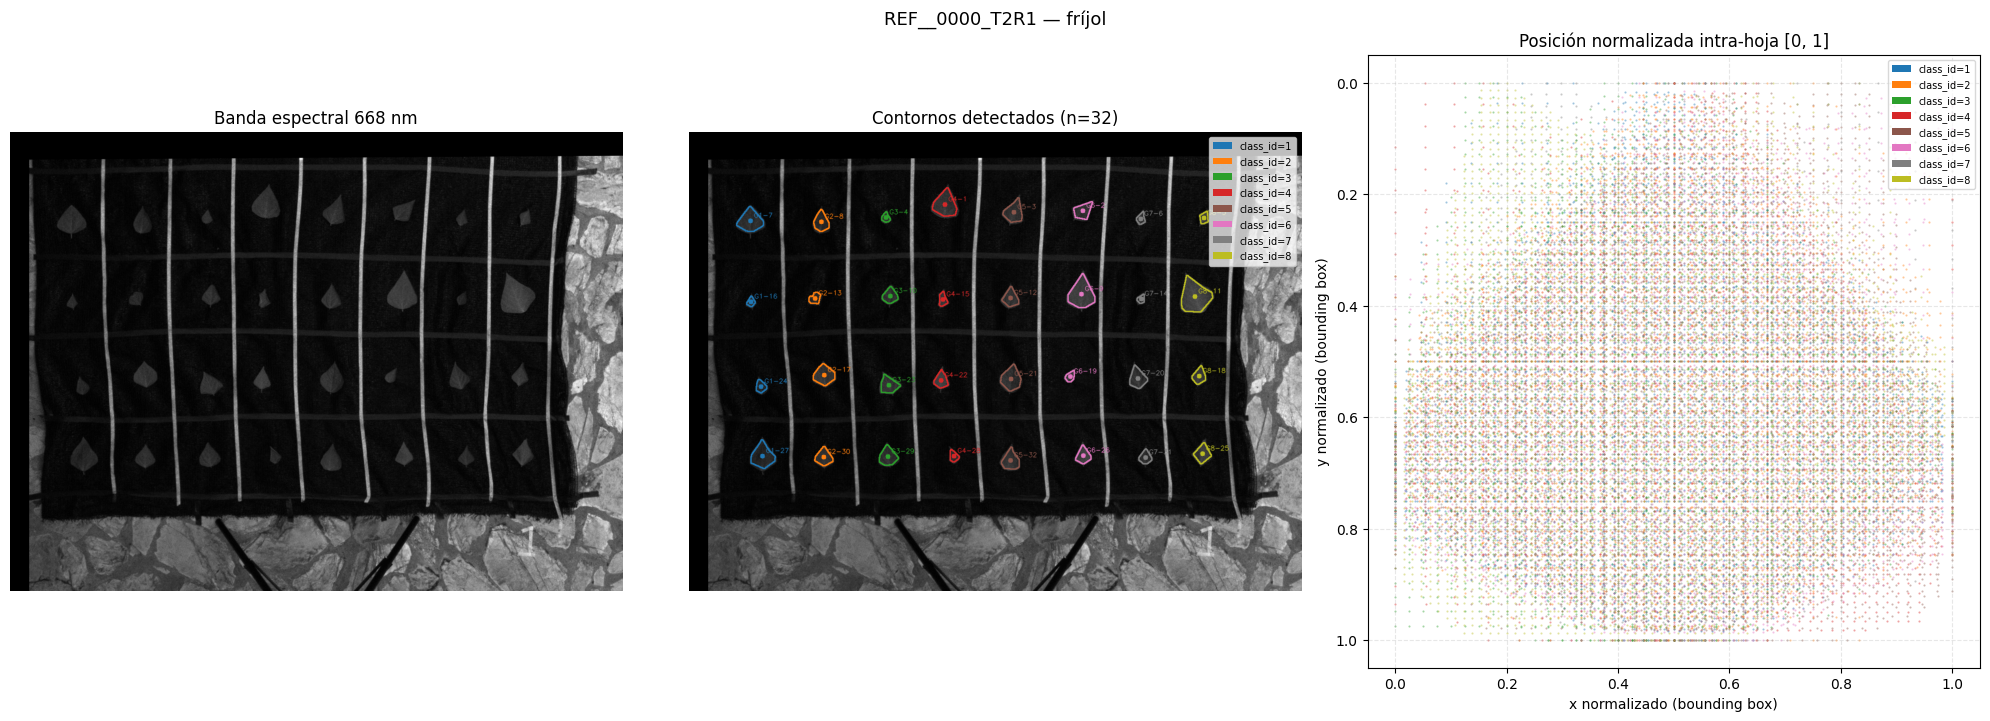

In [9]:
# Verificación fríjol T2R1
# expected_counts: 1 hoja por class_id (8 genotipos → 8 hojas en total)
expected_frijol = {cid: 4 for cid in range(1, 9)}

objetos_frijol, ok_frijol = verificar_objetos_detectados(
    mask=imagen_base_mask,
    image_band=imagen_base[:, :, 6],   # banda 668 nm como referencia visual
    image_nombre="REF__0000_T2R1 — fríjol",
    min_area=120,
    opening_kernel=3,
    expected_counts=expected_frijol,
    band_label="668 nm",
)

**Verificación maíz — 1 genotipo**

Maíz T1R1G1: una hoja por genotipo (1 clase → 1 objeto esperado).

Clases en máscara maíz 1G: [1]

Imagen: REF__0001_T1R1G1 — maíz 1G
  Total objetos detectados: 12
  class_id=1: 12 hoja(s) ✅
  Resultado: ✅ CONTEO CORRECTO


Clases en máscara maíz 1G: [1]

Imagen: REF__0001_T1R1G1 — maíz 1G
  Total objetos detectados: 12
  class_id=1: 12 hoja(s) ✅
  Resultado: ✅ CONTEO CORRECTO


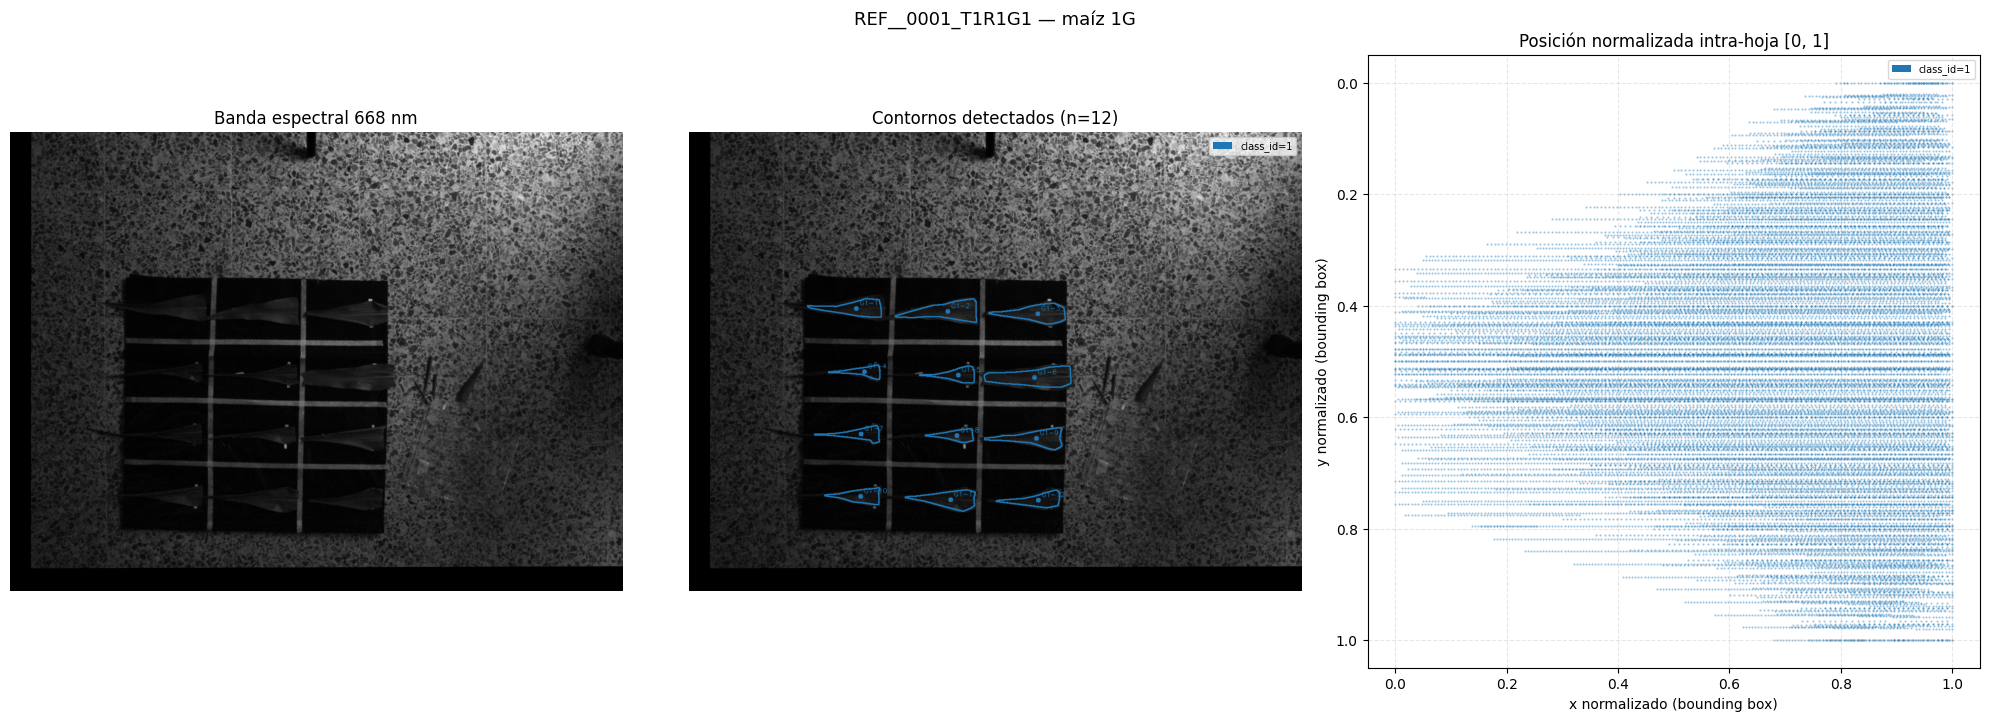

In [10]:
# Verificación maíz 1G — T1R1G1
# Inspeccionar primero cuántas clases hay en la máscara
clases_1G = np.sort(np.unique(imagen_base_mask_corn_1G))
clases_1G = clases_1G[clases_1G != 0]
print(f"Clases en máscara maíz 1G: {clases_1G}")

# Ajustar expected_counts según las clases reales
expected_maiz_1G = {int(cid): 12 for cid in clases_1G}

objetos_maiz_1G, ok_maiz_1G = verificar_objetos_detectados(
    mask=imagen_base_mask_corn_1G,
    image_band=imagen_base_corn_1G[:, :, 6],
    image_nombre="REF__0001_T1R1G1 — maíz 1G",
    min_area=200,
    opening_kernel=3,
    expected_counts=expected_maiz_1G,
    band_label="668 nm",
)

**Verificación maíz — 2 genotipos**

Maíz T1R1G10G4: dos genotipos por imagen. Ajusta `expected_counts` según las clases reales visibles en la imagen.

Clases en máscara maíz 2G: [1 2]

Imagen: REF__0002_T1R1G10G4 — maíz 2G
  Total objetos detectados: 8
  class_id=1: 4 hoja(s) ✅
  class_id=2: 4 hoja(s) ✅
  Resultado: ✅ CONTEO CORRECTO


Clases en máscara maíz 2G: [1 2]

Imagen: REF__0002_T1R1G10G4 — maíz 2G
  Total objetos detectados: 8
  class_id=1: 4 hoja(s) ✅
  class_id=2: 4 hoja(s) ✅
  Resultado: ✅ CONTEO CORRECTO


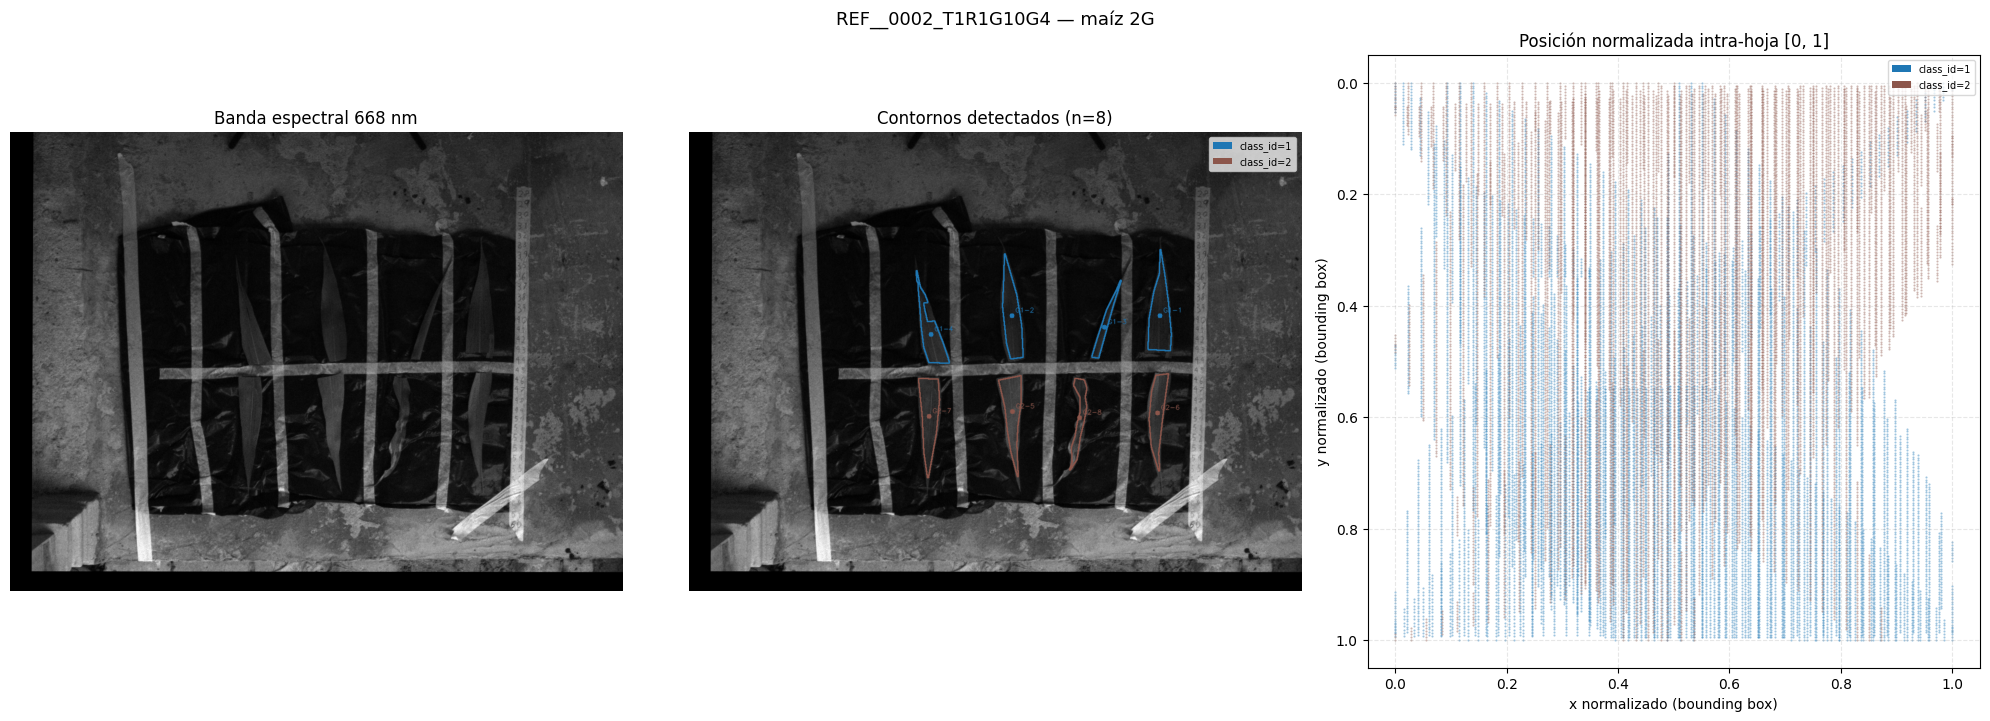

In [11]:
# Verificación maíz 2G — T1R1G10G4
clases_2G = np.sort(np.unique(imagen_base_mask_corn_2G))
clases_2G = clases_2G[clases_2G != 0]
print(f"Clases en máscara maíz 2G: {clases_2G}")

# Ajustar expected_counts si conoces el número de hojas por genotipo
expected_maiz_2G = {int(cid): 4 for cid in clases_2G}  # ajustar si una clase tiene más de 1 hoja

objetos_maiz_2G, ok_maiz_2G = verificar_objetos_detectados(
    mask=imagen_base_mask_corn_2G,
    image_band=imagen_base_corn_2G[:, :, 6],
    image_nombre="REF__0002_T1R1G10G4 — maíz 2G",
    min_area=200,
    opening_kernel=3,
    expected_counts=expected_maiz_2G,
    band_label="668 nm",
)

## 3.2 Contexto vecinal 3×3 enmascarado

La función `compute_neighborhood_stats_all_bands` calcula, **para cada banda y cada píxel de la máscara**, la media y la desviación estándar de sus 8 vecinos inmediatos que también están dentro de la máscara de la hoja.

**Detalles de implementación:**
1. Los píxeles fuera de la máscara se marcan como `NaN` para que no contaminen las estadísticas.
2. Se generan 8 vistas desplazadas del array (una por vecino) mediante slicing sobre un array acolchado con `NaN`.
3. `np.nanmean` / `np.nanstd` ignoran los `NaN`, por lo que los píxeles de borde promedian sólo sus vecinos válidos.
4. Para píxeles completamente aislados (todos los vecinos son fondo), la media cae de vuelta al valor propio y la std se fija a 0.

In [12]:
def compute_neighborhood_stats_all_bands(
    image: np.ndarray,
    mask: np.ndarray,
) -> tuple:
    """
    Calcula la media y desviación estándar de los 8 vecinos inmediatos de cada
    píxel dentro de la máscara, para todas las bandas espectrales.

    Los píxeles de fondo (mask == 0) se excluyen del cómputo vecinal reemplazándolos
    con NaN antes de desplazar, de modo que los bordes de hoja sólo promedian
    vecinos de hoja.

    Args:
        image : ndarray (H, W, C)  – cubo hiperespectral (valores uint8 o float).
        mask  : ndarray (H, W)     – máscara de clase; fondo == 0.

    Returns:
        mean_bands : ndarray (H, W, C) – media vecinal por banda.
        std_bands  : ndarray (H, W, C) – std vecinal por banda.
                     Fuera de la máscara los valores son 0 (no se usan).
    """
    H, W, C = image.shape
    mask_bool = mask > 0

    # Offsets de los 8 vecinos (fila, columna)
    offsets = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1),
    ]

    mean_bands = np.zeros((H, W, C), dtype=np.float32)
    std_bands  = np.zeros((H, W, C), dtype=np.float32)

    for c in range(C):
        band = image[:, :, c].astype(np.float64)

        # Fondo → NaN para que no participe en las estadísticas vecinales
        masked_band = np.where(mask_bool, band, np.nan)

        # Acolchar con NaN para manejar bordes de imagen sin condicionales
        padded = np.pad(masked_band, pad_width=1, mode='constant', constant_values=np.nan)

        # Apilar los 8 vecinos como planos independientes: shape (8, H, W)
        neighbor_stack = np.empty((8, H, W), dtype=np.float64)
        for k, (dr, dc) in enumerate(offsets):
            r0 = 1 + dr
            c0 = 1 + dc
            neighbor_stack[k] = padded[r0: r0 + H, c0: c0 + W]

        # Ignorar advertencias de nanmean/nanstd sobre rebanadas todas-NaN
        with np.errstate(all='ignore'):
            mean_c = np.nanmean(neighbor_stack, axis=0)  # (H, W)
            std_c  = np.nanstd( neighbor_stack, axis=0)  # (H, W)

        # Píxeles aislados (todos los vecinos son fondo): heredan su propio valor
        isolated = mask_bool & np.all(np.isnan(neighbor_stack), axis=0)
        mean_c[isolated] = band[isolated]
        std_c[isolated]  = 0.0

        mean_bands[:, :, c] = mean_c
        std_bands[:, :, c]  = std_c

    return mean_bands, std_bands

### 3.2.1 Validación visual del contexto vecinal

Se comparan la banda original, la media vecinal y la std vecinal para una imagen de ejemplo. La media debe verse como una versión suavizada de la banda; la std debe ser alta en zonas de transición (borde de hoja o manchas de estrés) y baja en regiones homogéneas.

C:\Users\ssola\AppData\Local\Temp\ipykernel_22784\3562678340.py:53: RuntimeWarning: Mean of empty slice
  mean_c = np.nanmean(neighbor_stack, axis=0)  # (H, W)


C:\Users\ssola\AppData\Local\Temp\ipykernel_22784\3562678340.py:53: RuntimeWarning: Mean of empty slice
  mean_c = np.nanmean(neighbor_stack, axis=0)  # (H, W)


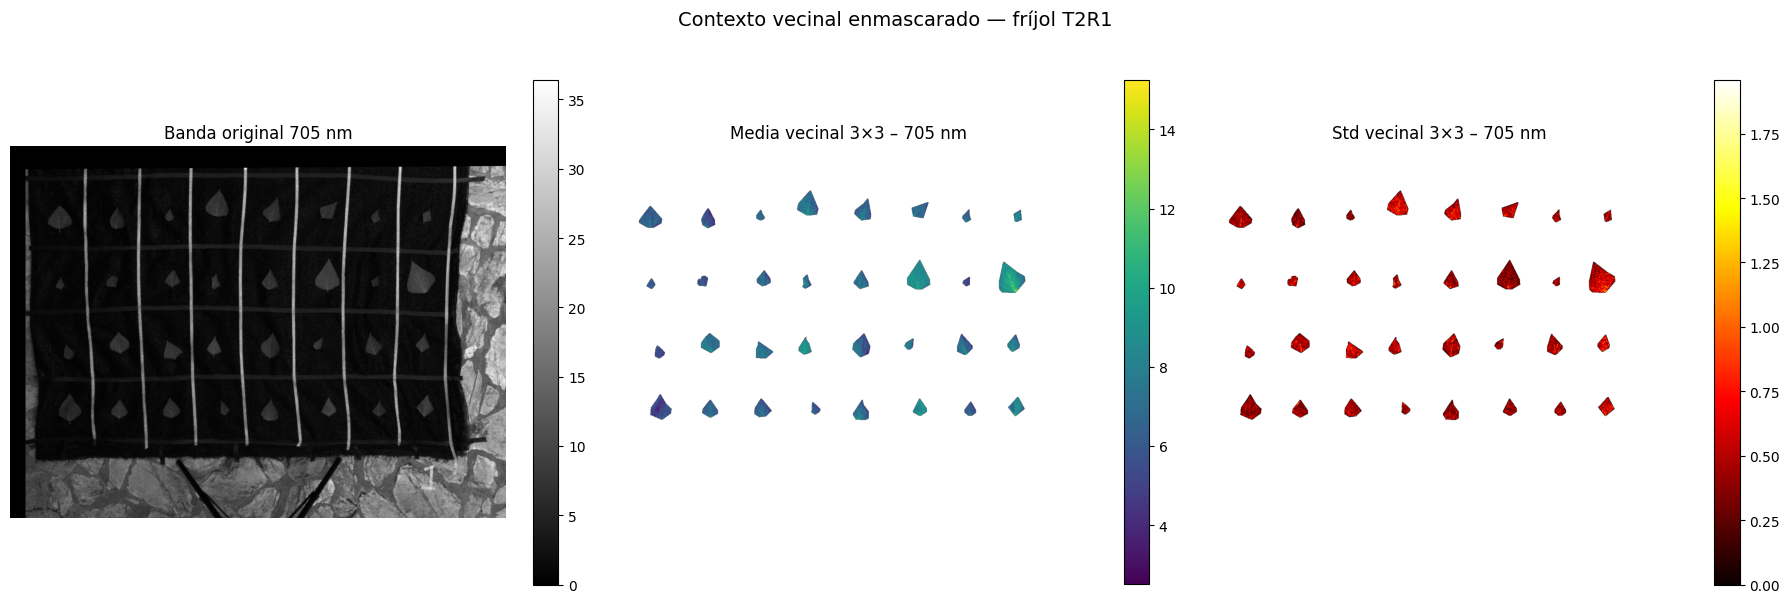

Banda 705 nm — píxeles en máscara: 32543
  Media vecinal: min=3.12, max=13.78, promedio=7.22
  Std vecinal:   min=0.00, max=1.96, promedio=0.49


In [15]:
# Calcular contexto vecinal para imagen de ejemplo (fríjol)
mean_ex, std_ex = compute_neighborhood_stats_all_bands(imagen_base, imagen_base_mask)

BAND_IDX = 6  # banda de ejemplo
banda_nm = longitudes_de_onda[BAND_IDX]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(imagen_base[:, :, BAND_IDX], cmap='gray')
axes[0].set_title(f'Banda original {banda_nm} nm')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mean_ex[:, :, BAND_IDX], cmap='viridis')
axes[1].set_title(f'Media vecinal 3×3 – {banda_nm} nm')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(std_ex[:, :, BAND_IDX], cmap='hot')
axes[2].set_title(f'Std vecinal 3×3 – {banda_nm} nm')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle('Contexto vecinal enmascarado — fríjol T2R1', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Estadísticas rápidas dentro de la máscara
mask_bool_ex = imagen_base_mask > 0
print(f"Banda {banda_nm} nm — píxeles en máscara: {mask_bool_ex.sum()}")
print(f"  Media vecinal: min={mean_ex[:,:,BAND_IDX][mask_bool_ex].min():.2f}, "
      f"max={mean_ex[:,:,BAND_IDX][mask_bool_ex].max():.2f}, "
      f"promedio={mean_ex[:,:,BAND_IDX][mask_bool_ex].mean():.2f}")
print(f"  Std vecinal:   min={std_ex[:,:,BAND_IDX][mask_bool_ex].min():.2f}, "
      f"max={std_ex[:,:,BAND_IDX][mask_bool_ex].max():.2f}, "
      f"promedio={std_ex[:,:,BAND_IDX][mask_bool_ex].mean():.2f}")

### 3.2.2 Verificación de manejo de bordes

Se verifica que los píxeles en el borde de la hoja tienen un número reducido de vecinos válidos y que su media/std se calculan correctamente a partir de sólo esos vecinos.

Distribución de vecinos válidos por píxel de hoja:
  1 vecinos válidos: 3 píxeles (0.0%)
  2 vecinos válidos: 19 píxeles (0.1%)
  3 vecinos válidos: 52 píxeles (0.2%)
  4 vecinos válidos: 882 píxeles (2.7%)
  5 vecinos válidos: 1564 píxeles (4.8%)
  6 vecinos válidos: 795 píxeles (2.4%)
  7 vecinos válidos: 1559 píxeles (4.8%)
  8 vecinos válidos: 27669 píxeles (85.0%)


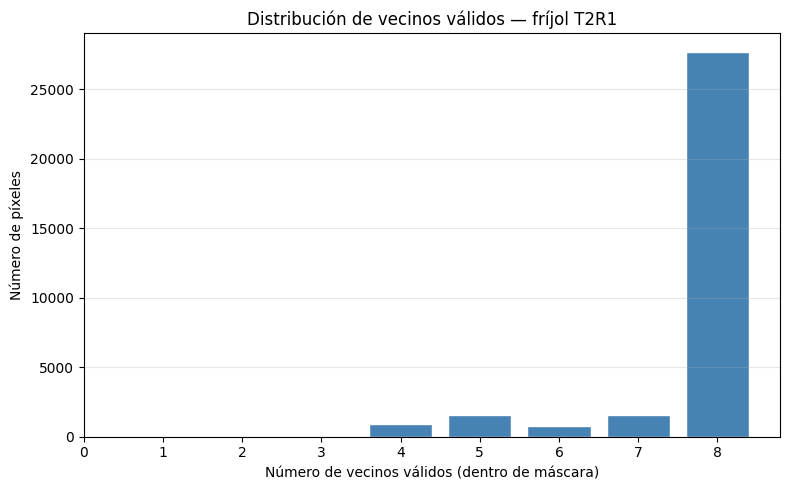

In [16]:
def contar_vecinos_validos(mask: np.ndarray) -> np.ndarray:
    """Devuelve un array (H, W) con el número de vecinos válidos (dentro de máscara) para cada píxel."""
    mask_bool = (mask > 0).astype(np.float64)
    padded = np.pad(mask_bool, 1, mode='constant', constant_values=0)
    offsets = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    H, W = mask.shape
    count = np.zeros((H, W), dtype=np.int32)
    for dr, dc in offsets:
        r0, c0 = 1 + dr, 1 + dc
        count += padded[r0: r0+H, c0: c0+W].astype(np.int32)
    return count

vecinos = contar_vecinos_validos(imagen_base_mask)
mask_bool_ex = imagen_base_mask > 0

# Distribución de vecinos dentro de la máscara
vals, cnts = np.unique(vecinos[mask_bool_ex], return_counts=True)
print("Distribución de vecinos válidos por píxel de hoja:")
for v, c in zip(vals, cnts):
    print(f"  {v} vecinos válidos: {c} píxeles ({100*c/mask_bool_ex.sum():.1f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(vals, cnts, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de vecinos válidos (dentro de máscara)')
ax.set_ylabel('Número de píxeles')
ax.set_title('Distribución de vecinos válidos — fríjol T2R1')
ax.set_xticks(range(9))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3.3 Funciones auxiliares del pipeline

In [17]:
# Función para cargar imagen multiespectral desde .mat
def cargar_imagen_mat(filepath):
    mat_data = loadmat(filepath)
    return mat_data['R']


# Función para cargar máscara desde .mat
def cargar_mask_mat(filepath):
    mat_class_data = loadmat(filepath)
    return mat_class_data['class_map']

In [18]:
def append_csv(df_final: pd.DataFrame, output_csv_path: str):
    """Agrega filas a un CSV sin recargarlo completo en memoria."""
    if df_final is None or df_final.empty:
        return
    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
    write_header = not os.path.exists(output_csv_path)
    df_final.to_csv(output_csv_path, mode='a', header=write_header, index=False)

In [19]:
def construir_split_objetos(object_data, train_ratio: float = 0.7, seed: int = 42):
    """Genera split train/test por objeto con estratificación por tratamiento."""
    if not object_data:
        return {}

    first = object_data[0]

    # Caso estratificado: [{"object_id": ..., "tratamiento": ...}, ...]
    if isinstance(first, dict) and "object_id" in first and "tratamiento" in first:
        df = pd.DataFrame(object_data).drop_duplicates(subset=["object_id"]).copy()
        df["object_id"] = df["object_id"].astype(str)

        rng = np.random.default_rng(seed)
        split_map = {}

        for tratamiento in sorted(df["tratamiento"].dropna().unique()):
            ids_trat = sorted(df.loc[df["tratamiento"] == tratamiento, "object_id"].tolist())
            if not ids_trat:
                continue

            perm = rng.permutation(len(ids_trat))
            n_train = int(round(len(ids_trat) * float(train_ratio)))
            n_train = max(1, min(n_train, len(ids_trat) - 1)) if len(ids_trat) > 1 else 1

            for rank, idx in enumerate(perm):
                obj_id = ids_trat[idx]
                split_map[obj_id] = "train" if rank < n_train else "test"

        return split_map

    # Caso legacy: [object_id, object_id, ...]
    object_ids_unicos = sorted(set(object_data))
    if not object_ids_unicos:
        return {}

    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(object_ids_unicos))
    n_train = int(round(len(object_ids_unicos) * float(train_ratio)))
    n_train = max(1, min(n_train, len(object_ids_unicos) - 1)) if len(object_ids_unicos) > 1 else 1

    split_map = {}
    for rank, idx in enumerate(perm):
        obj_id = object_ids_unicos[idx]
        split_map[obj_id] = "train" if rank < n_train else "test"

    return split_map

### 3.3.1 Fríjol

Pipeline completo para fríjol: empareja archivos `REF`/`CLASS`, construye el split estratificado por tratamiento, calcula el contexto vecinal enmascarado por imagen y exporta los CSV de train/test.

In [20]:
# Definir longitudes de onda
longitudes_de_onda = [444, 475, 531, 560, 650, 668, 705, 717, 740, 848]

In [21]:
ruta_principal = "data/mat"
cultivo = "frijol"

ruta_cultivo = os.path.join(ruta_principal, cultivo)
output_csv_train    = f"datasets/dataset_{cultivo}_fix_obj_train_v5.csv"
output_csv_test     = f"datasets/dataset_{cultivo}_fix_obj_test_v5.csv"
output_split_manifest = f"datasets/object_split_{cultivo}_v5.csv"

for p in [output_csv_train, output_csv_test, output_split_manifest]:
    if os.path.exists(p):
        os.remove(p)

tiempo_total_inicio = time.time()
procesadas = 0

SPLIT_SEED   = 42
TRAIN_RATIO  = 0.7

treatment_pattern = re.compile(r"_T(\d+)")

# ── Pasada 1: recolectar IDs de objeto + tratamiento para split estratificado ─────────
image_records  = []
all_object_rows = []

for fecha in os.listdir(ruta_cultivo):
    ruta_fecha = os.path.join(ruta_cultivo, fecha)
    if not os.path.isdir(ruta_fecha):
        continue

    masks  = sorted([f for f in os.listdir(ruta_fecha) if f.startswith("CLASS__") and f.endswith(".mat")])
    images = sorted([f for f in os.listdir(ruta_fecha) if f.startswith("REF__")   and f.endswith(".mat")])

    for img_file, mask_file in zip(images, masks):
        img_path  = os.path.join(ruta_fecha, img_file)
        mask_path = os.path.join(ruta_fecha, mask_file)

        nombre = os.path.splitext(img_file)[0]
        match  = treatment_pattern.search(nombre)
        tratamiento_key = int(match.group(1)) if match else 0

        try:
            mask    = cargar_mask_mat(mask_path)
            objetos = construir_objetos_desde_mask(mask, min_area=120, opening_kernel=3)
            object_ids = [f"{nombre}__obj_{obj['object_local_id']:03d}" for obj in objetos]
            all_object_rows.extend(
                [{"object_id": oid, "tratamiento": int(tratamiento_key)} for oid in object_ids]
            )
            image_records.append({
                "img_path":   img_path,
                "mask_path":  mask_path,
                "img_file":   img_file,
                "nombre":     nombre,
                "tratamiento": tratamiento_key,
            })
        except Exception as e:
            print(f"Error preparando split para {img_file}: {e}")

split_map = construir_split_objetos(all_object_rows, train_ratio=TRAIN_RATIO, seed=SPLIT_SEED)
if not split_map:
    raise ValueError("No se encontraron objetos para construir el split.")

# Guardar manifiesto de split
tratamiento_map = {row["object_id"]: int(row["tratamiento"]) for row in all_object_rows}
split_manifest_df = (
    pd.DataFrame([
        {"object_id": oid, "tratamiento": tratamiento_map.get(oid, -1), "split": spl}
        for oid, spl in split_map.items()
    ])
    .drop_duplicates(subset=["object_id"])
    .sort_values(["tratamiento", "object_id"])
    .reset_index(drop=True)
)
split_manifest_df.to_csv(output_split_manifest, index=False)

conteo_split = split_manifest_df["split"].value_counts().to_dict()
print(f"Split por objeto ({cultivo}): {conteo_split}")
print("Distribución por tratamiento y split:")
print(split_manifest_df.groupby(["tratamiento", "split"]).size().unstack(fill_value=0).to_string())

# ── Pasada 2: extraer features con contexto vecinal ────────────────────────────────────
print(f"\n🔹 Procesando cultivo: {cultivo}")

for rec in image_records:
    try:
        image = cargar_imagen_mat(rec["img_path"])
        mask  = cargar_mask_mat(rec["mask_path"])

        # ── Calcular contexto vecinal una sola vez por imagen ──────────────────
        mean_bands, std_bands = compute_neighborhood_stats_all_bands(image, mask)

        objetos = construir_objetos_desde_mask(mask, min_area=120, opening_kernel=3)

        rows_train, rows_test = [], []
        start_time = time.time()

        for obj in objetos:
            object_id = f"{rec['nombre']}__obj_{obj['object_local_id']:03d}"
            split     = split_map.get(object_id, "train")

            px = obj["pixels_x"]
            py = obj["pixels_y"]

            pixel_data = {
                "pixel_relativo_x": np.round((px - obj["cx"]).astype(float), 2),
                "pixel_relativo_y": np.round((py - obj["cy"]).astype(float), 2),
                "genotipo":         int(obj["class_id"]),
                "tratamiento":      int(rec["tratamiento"]),
                "object_id":        object_id,
                "split":            split,
            }

            for ch, banda in enumerate(longitudes_de_onda):
                if ch < image.shape[2]:
                    pixel_data[f"int_{banda}"]  = image[py, px, ch].astype(np.uint8)
                    pixel_data[f"mean_{banda}"] = np.round(mean_bands[py, px, ch].astype(float), 4)
                    pixel_data[f"std_{banda}"]  = np.round(std_bands[py, px, ch].astype(float), 4)

            df_obj = pd.DataFrame(pixel_data)
            (rows_train if split == "train" else rows_test).append(df_obj)

        if rows_train:
            append_csv(pd.concat(rows_train, ignore_index=True), output_csv_train)
        if rows_test:
            append_csv(pd.concat(rows_test,  ignore_index=True), output_csv_test)

        procesadas += 1
        if procesadas % 20 == 0:
            print(
                f"✅ Procesada {rec['img_file']} | "
                f"objetos: {len(objetos)} | tiempo: {time.time()-start_time:.2f}s"
            )

    except Exception as e:
        print(f"Error cargando {rec['img_file']}: {e}")

print(f"\n🕒 Tiempo total de procesamiento: {time.time()-tiempo_total_inicio:.2f}s")
print(f"CSV train: {output_csv_train}")
print(f"CSV test:  {output_csv_test}")
print(f"Manifest:  {output_split_manifest}")

Split por objeto (frijol): {'train': 267, 'test': 115}
Distribución por tratamiento y split:
split        test  train
tratamiento             
1              29     67
2              29     67
3              29     67
4              28     66

🔹 Procesando cultivo: frijol


Split por objeto (frijol): {'train': 267, 'test': 115}
Distribución por tratamiento y split:
split        test  train
tratamiento             
1              29     67
2              29     67
3              29     67
4              28     66

🔹 Procesando cultivo: frijol


C:\Users\ssola\AppData\Local\Temp\ipykernel_22784\3562678340.py:53: RuntimeWarning: Mean of empty slice
  mean_c = np.nanmean(neighbor_stack, axis=0)  # (H, W)
c:\Users\ssola\Documents\SELENE\UNAL\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Split por objeto (frijol): {'train': 267, 'test': 115}
Distribución por tratamiento y split:
split        test  train
tratamiento             
1              29     67
2              29     67
3              29     67
4              28     66

🔹 Procesando cultivo: frijol


C:\Users\ssola\AppData\Local\Temp\ipykernel_22784\3562678340.py:53: RuntimeWarning: Mean of empty slice
  mean_c = np.nanmean(neighbor_stack, axis=0)  # (H, W)
c:\Users\ssola\Documents\SELENE\UNAL\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



🕒 Tiempo total de procesamiento: 58.07s
CSV train: datasets/dataset_frijol_fix_obj_train_v5.csv
CSV test:  datasets/dataset_frijol_fix_obj_test_v5.csv
Manifest:  datasets/object_split_frijol_v5.csv


### 3.3.2 Maíz

Pipeline análogo para maíz. Requiere mapear múltiples genotipos por imagen a partir del nombre de archivo. Se reutiliza el contexto vecinal calculado por imagen.

In [22]:
def extraer_genotipos(nombre_archivo: str):
    """
    Extrae los genotipos del nombre de archivo basándose
    en el patrón ...R<repeticion>G<id>(G<id>)* al final.
    Ej: REF__0002_T1R1G10G4 -> [10, 4]
    """
    base = os.path.splitext(nombre_archivo)[0]
    m = re.search(r"R\d+((?:G\d+)+)$", base)
    if not m:
        gens = re.findall(r"G\d+", base)
    else:
        gens = re.findall(r"G\d+", m.group(1))
    return [int(g[1:]) for g in gens]

In [23]:
ruta_principal = "data/mat"
cultivo = "maiz"

ruta_cultivo = os.path.join(ruta_principal, cultivo)
output_csv_train    = f"datasets/dataset_{cultivo}_fix_obj_train_v5.csv"
output_csv_test     = f"datasets/dataset_{cultivo}_fix_obj_test_v5.csv"
output_split_manifest = f"datasets/object_split_{cultivo}_v5.csv"

for p in [output_csv_train, output_csv_test, output_split_manifest]:
    if os.path.exists(p):
        os.remove(p)

tiempo_total_inicio = time.time()
procesadas = 0

SPLIT_SEED  = 42
TRAIN_RATIO = 0.7

treatment_pattern = re.compile(r"_T(\d+)")

image_records   = []
all_object_rows = []

# ── Pasada 1: recolectar IDs de objeto + tratamiento ──────────────────────────────────
for fecha in os.listdir(ruta_cultivo):
    ruta_fecha = os.path.join(ruta_cultivo, fecha)
    if not os.path.isdir(ruta_fecha):
        continue

    masks  = [f for f in os.listdir(ruta_fecha) if f.startswith("CLASS") and f.endswith(".mat")]
    images = [f for f in os.listdir(ruta_fecha) if f.startswith("REF")   and f.endswith(".mat")]

    masks_dict = {m.replace("CLASS__", "").replace("CLASS_", ""): m for m in masks}

    for img_file in sorted(images):
        img_key   = img_file.replace("REF__", "").replace("REF_", "")
        mask_file = masks_dict.get(img_key)
        if mask_file is None:
            continue

        img_path  = os.path.join(ruta_fecha, img_file)
        mask_path = os.path.join(ruta_fecha, mask_file)

        nombre = os.path.splitext(img_file)[0]
        match  = treatment_pattern.search(nombre)
        tratamiento_key = int(match.group(1)) if match else 0

        try:
            mask    = cargar_mask_mat(mask_path)
            objetos = construir_objetos_desde_mask(mask, min_area=200, opening_kernel=3)
            object_ids = [f"{nombre}__obj_{obj['object_local_id']:03d}" for obj in objetos]
            all_object_rows.extend(
                [{"object_id": oid, "tratamiento": int(tratamiento_key)} for oid in object_ids]
            )
            image_records.append({
                "img_path":    img_path,
                "mask_path":   mask_path,
                "img_file":    img_file,
                "nombre":      nombre,
                "tratamiento": tratamiento_key,
            })
        except Exception as e:
            print(f"Error preparando split para {img_file}: {e}")

split_map = construir_split_objetos(all_object_rows, train_ratio=TRAIN_RATIO, seed=SPLIT_SEED)
if not split_map:
    raise ValueError("No se encontraron objetos para construir el split.")

tratamiento_map = {row["object_id"]: int(row["tratamiento"]) for row in all_object_rows}
split_manifest_df = (
    pd.DataFrame([
        {"object_id": oid, "tratamiento": tratamiento_map.get(oid, -1), "split": spl}
        for oid, spl in split_map.items()
    ])
    .drop_duplicates(subset=["object_id"])
    .sort_values(["tratamiento", "object_id"])
    .reset_index(drop=True)
)
split_manifest_df.to_csv(output_split_manifest, index=False)

conteo_split = split_manifest_df["split"].value_counts().to_dict()
print(f"Split por objeto ({cultivo}): {conteo_split}")
print("Distribución por tratamiento y split:")
print(split_manifest_df.groupby(["tratamiento", "split"]).size().unstack(fill_value=0).to_string())

# ── Pasada 2: extraer features con contexto vecinal ────────────────────────────────────
print(f"\n🔹 Procesando cultivo: {cultivo}")

for rec in image_records:
    try:
        imagen = cargar_imagen_mat(rec["img_path"])
        mask   = cargar_mask_mat(rec["mask_path"])

        nombre    = rec["nombre"]
        genotipos = extraer_genotipos(rec["img_file"])

        clases_presentes = np.sort(np.unique(mask))
        clases_presentes = clases_presentes[clases_presentes != 0]

        if len(genotipos) == 0:
            genotipos = [0]
        mapping = {
            obj_id: genotipos[i % len(genotipos)]
            for i, obj_id in enumerate(clases_presentes)
        }

        # ── Calcular contexto vecinal una sola vez por imagen ──────────────────
        mean_bands, std_bands = compute_neighborhood_stats_all_bands(imagen, mask)

        objetos = construir_objetos_desde_mask(mask, min_area=200, opening_kernel=3)

        rows_train, rows_test = [], []
        start_time = time.time()

        for obj in objetos:
            object_id      = f"{nombre}__obj_{obj['object_local_id']:03d}"
            split          = split_map.get(object_id, "train")
            genotipo_mapeado = int(mapping.get(int(obj["class_id"]), 0))

            px = obj["pixels_x"]
            py = obj["pixels_y"]

            pixel_data = {
                "pixel_relativo_x": np.round((px - obj["cx"]).astype(float), 2),
                "pixel_relativo_y": np.round((py - obj["cy"]).astype(float), 2),
                "genotipo":         genotipo_mapeado,
                "tratamiento":      int(rec["tratamiento"]),
                "object_id":        object_id,
                "split":            split,
            }

            for ch, banda in enumerate(longitudes_de_onda):
                if ch < imagen.shape[2]:
                    pixel_data[f"int_{banda}"]  = imagen[py, px, ch].astype(np.uint8)
                    pixel_data[f"mean_{banda}"] = np.round(mean_bands[py, px, ch].astype(float), 4)
                    pixel_data[f"std_{banda}"]  = np.round(std_bands[py, px, ch].astype(float), 4)

            df_obj = pd.DataFrame(pixel_data)
            (rows_train if split == "train" else rows_test).append(df_obj)

        if rows_train:
            append_csv(pd.concat(rows_train, ignore_index=True), output_csv_train)
        if rows_test:
            append_csv(pd.concat(rows_test,  ignore_index=True), output_csv_test)

        procesadas += 1
        if procesadas % 50 == 0:
            print(
                f"✅ Procesada {rec['img_file']} | "
                f"objetos: {len(objetos)} | tiempo: {time.time()-start_time:.2f}s"
            )

    except Exception as e:
        print(f"Error cargando {rec['img_path']}: {e}")

print(f"\n🕒 Tiempo total de procesamiento: {time.time()-tiempo_total_inicio:.2f}s")
print(f"CSV train: {output_csv_train}")
print(f"CSV test:  {output_csv_test}")
print(f"Manifest:  {output_split_manifest}")

Split por objeto (maiz): {'train': 401, 'test': 172}
Distribución por tratamiento y split:
split        test  train
tratamiento             
1              55    130
2              50    116
3              34     78
4              33     77

🔹 Procesando cultivo: maiz


Split por objeto (maiz): {'train': 401, 'test': 172}
Distribución por tratamiento y split:
split        test  train
tratamiento             
1              55    130
2              50    116
3              34     78
4              33     77

🔹 Procesando cultivo: maiz


C:\Users\ssola\AppData\Local\Temp\ipykernel_22784\3562678340.py:53: RuntimeWarning: Mean of empty slice
  mean_c = np.nanmean(neighbor_stack, axis=0)  # (H, W)
c:\Users\ssola\Documents\SELENE\UNAL\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Split por objeto (maiz): {'train': 401, 'test': 172}
Distribución por tratamiento y split:
split        test  train
tratamiento             
1              55    130
2              50    116
3              34     78
4              33     77

🔹 Procesando cultivo: maiz


C:\Users\ssola\AppData\Local\Temp\ipykernel_22784\3562678340.py:53: RuntimeWarning: Mean of empty slice
  mean_c = np.nanmean(neighbor_stack, axis=0)  # (H, W)
c:\Users\ssola\Documents\SELENE\UNAL\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


✅ Procesada REF__0058_T2R3G5G2.mat | objetos: 8 | tiempo: 0.94s

🕒 Tiempo total de procesamiento: 278.65s
CSV train: datasets/dataset_maiz_fix_obj_train_v5.csv
CSV test:  datasets/dataset_maiz_fix_obj_test_v5.csv
Manifest:  datasets/object_split_maiz_v5.csv


# 4. QA del dataset v5

> Validación del proceso con contexto vecinal (`*_fix_obj_train_v5.csv`, `*_fix_obj_test_v5.csv`, `object_split_*_v5.csv`).

Verifica:
- Existencia de archivos de salida.
- Esquema esperado de columnas (36 por fila): `pixel_relativo_x/y`, 10 × `int_*`, 10 × `mean_*`, 10 × `std_*`, `genotipo`, `tratamiento`, `object_id`, `split`.
- Sin fuga de objetos entre train y test.
- Rangos de las nuevas features: `mean_*` ∈ [0, 255], `std_*` ≥ 0.
- Consistencia columna `split` vs manifiesto.

In [24]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from scipy.io import loadmat

if "longitudes_de_onda" not in globals():
    longitudes_de_onda = [444, 475, 531, 560, 650, 668, 705, 717, 740, 848]

if "TRAIN_RATIO" not in globals():
    TRAIN_RATIO = 0.7

In [25]:
def verificar_dataset_v5(cultivo: str, expected_ratio: float = 0.7, ratio_tolerance: float = 0.12):
    band_cols = [f"int_{b}"  for b in longitudes_de_onda]
    mean_cols = [f"mean_{b}" for b in longitudes_de_onda]
    std_cols  = [f"std_{b}"  for b in longitudes_de_onda]

    paths = {
        "train":    f"datasets/dataset_{cultivo}_fix_obj_train_v5.csv",
        "test":     f"datasets/dataset_{cultivo}_fix_obj_test_v5.csv",
        "manifest": f"datasets/object_split_{cultivo}_v5.csv",
    }

    print(f"\n=== QA v5 — {cultivo.upper()} ===")
    missing = [k for k, p in paths.items() if not os.path.exists(p)]
    if missing:
        print("Faltan archivos:", [paths[k] for k in missing])
        return None

    df_train  = pd.read_csv(paths["train"])
    df_test   = pd.read_csv(paths["test"])
    manifest  = pd.read_csv(paths["manifest"])

    required_cols = [
        "pixel_relativo_x", "pixel_relativo_y",
        "genotipo", "tratamiento", "object_id", "split",
    ] + band_cols + mean_cols + std_cols

    ok = True

    # ── Esquema ────────────────────────────────────────────────────────────────
    for name, df in [("train", df_train), ("test", df_test)]:
        missing_cols = [c for c in required_cols if c not in df.columns]
        if missing_cols:
            print(f"❌ {name}: faltan columnas {missing_cols}")
            ok = False
        else:
            print(f"✅ {name}: esquema de {len(required_cols)} columnas correcto")

    df_all = pd.concat([df_train, df_test], ignore_index=True)

    # ── Sin fuga ───────────────────────────────────────────────────────────────
    ids_train = set(df_train["object_id"].dropna().astype(str).unique())
    ids_test  = set(df_test["object_id"].dropna().astype(str).unique())
    overlap = ids_train & ids_test
    if overlap:
        print(f"❌ Fuga: {len(overlap)} object_id en train y test")
        ok = False
    else:
        print("✅ Sin fuga entre train y test")

    # ── Consistencia split vs manifest ─────────────────────────────────────────
    manifest_map = manifest.assign(
        object_id=manifest["object_id"].astype(str)
    ).set_index("object_id")["split"].to_dict()
    df_all["object_id"] = df_all["object_id"].astype(str)
    split_from_manifest = df_all["object_id"].map(manifest_map)
    mismatch = int(((~split_from_manifest.isna()) & (split_from_manifest != df_all["split"])).sum())
    if mismatch:
        print(f"❌ {mismatch} filas no coinciden con split del manifest")
        ok = False
    else:
        print("✅ Columna split consistente con el manifest")

    # ── Nulos ──────────────────────────────────────────────────────────────────
    null_counts = df_all[required_cols].isna().sum()
    total_nulls = int(null_counts.sum())
    if total_nulls > 0:
        print("❌ Nulos en columnas requeridas:")
        print(null_counts[null_counts > 0].to_string())
        ok = False
    else:
        print("✅ Sin nulos en columnas requeridas")

    # ── Rangos int_* ──────────────────────────────────────────────────────────
    in_range_int = ((df_all[band_cols] >= 0) & (df_all[band_cols] <= 255)).all().all()
    if not bool(in_range_int):
        print("❌ Intensidades originales fuera de [0,255]")
        ok = False
    else:
        print("✅ int_* en [0, 255]")

    # ── Rangos mean_* ─────────────────────────────────────────────────────────
    in_range_mean = ((df_all[mean_cols] >= 0) & (df_all[mean_cols] <= 255)).all().all()
    if not bool(in_range_mean):
        bad = int((~((df_all[mean_cols] >= 0) & (df_all[mean_cols] <= 255))).sum().sum())
        print(f"❌ mean_* fuera de [0,255] en {bad} celdas")
        ok = False
    else:
        print("✅ mean_* en [0, 255]")

    # ── Rangos std_* ──────────────────────────────────────────────────────────
    std_neg = int((df_all[std_cols] < 0).sum().sum())
    if std_neg > 0:
        print(f"❌ std_* negativo en {std_neg} celdas")
        ok = False
    else:
        print("✅ std_* ≥ 0")

    # ── Ratio de split ─────────────────────────────────────────────────────────
    obj_counts = manifest["split"].value_counts()
    n_train    = int(obj_counts.get("train", 0))
    n_test     = int(obj_counts.get("test",  0))
    n_total    = n_train + n_test
    ratio      = (n_train / n_total) if n_total > 0 else 0.0
    delta      = abs(ratio - expected_ratio)
    print(f"\nSplit por objeto: train={n_train}, test={n_test}, ratio_train={ratio:.4f}")
    if delta > ratio_tolerance:
        print(f"⚠️  Ratio fuera de tolerancia (delta={delta:.4f} > {ratio_tolerance})")
    else:
        print("✅ Ratio de split dentro de tolerancia")

    # ── Resumen por split ──────────────────────────────────────────────────────
    resumen = pd.DataFrame({
        "filas":             df_all.groupby("split").size(),
        "objetos_unicos":    df_all.groupby("split")["object_id"].nunique(),
        "genotipos_unicos":  df_all.groupby("split")["genotipo"].nunique(),
        "tratamientos_unicos": df_all.groupby("split")["tratamiento"].nunique(),
    }).fillna(0).astype(int)
    print("\nResumen por split:")
    print(resumen.to_string())

    # ── Estadísticas de features nuevas ───────────────────────────────────────
    mask_in = df_all["split"].notna()
    print("\nEstadísticas de mean_* (muestra de 3 bandas):")
    print(df_all[[f"mean_{b}" for b in longitudes_de_onda[:3]]].describe().to_string())
    print("\nEstadísticas de std_* (muestra de 3 bandas):")
    print(df_all[[f"std_{b}" for b in longitudes_de_onda[:3]]].describe().to_string())

    print("\nResultado global QA:")
    print("✅ APROBADO" if ok else "❌ REVISAR ANTES DE ENTRENAR")

    return {
        "ok":       ok,
        "train":    df_train,
        "test":     df_test,
        "manifest": manifest,
        "paths":    paths,
        "band_cols": band_cols,
        "mean_cols": mean_cols,
        "std_cols":  std_cols,
    }

In [26]:
qa_frijol = verificar_dataset_v5(
    cultivo="frijol",
    expected_ratio=float(TRAIN_RATIO),
    ratio_tolerance=0.12,
)


=== QA v5 — FRIJOL ===
✅ train: esquema de 36 columnas correcto
✅ test: esquema de 36 columnas correcto
✅ Sin fuga entre train y test
✅ Columna split consistente con el manifest
✅ Sin nulos en columnas requeridas
✅ int_* en [0, 255]
✅ mean_* en [0, 255]
✅ std_* ≥ 0

Split por objeto: train=267, test=115, ratio_train=0.6990
✅ Ratio de split dentro de tolerancia

Resumen por split:
        filas  objetos_unicos  genotipos_unicos  tratamientos_unicos
split                                                               
test    98308             115                 8                    4
train  231400             267                 8                    4

Estadísticas de mean_* (muestra de 3 bandas):
            mean_444       mean_475       mean_531
count  329708.000000  329708.000000  329708.000000
mean        2.090819       2.080607       4.839671
std         0.713140       0.626456       1.344444
min         0.225800       0.351900       0.593300
25%         1.587000       1.637000   

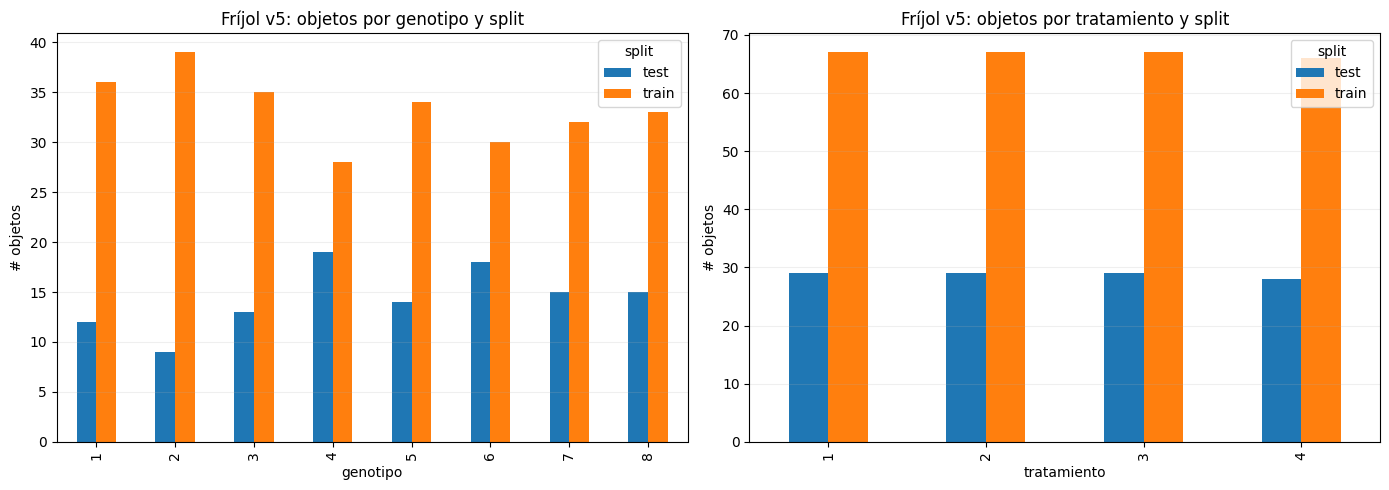

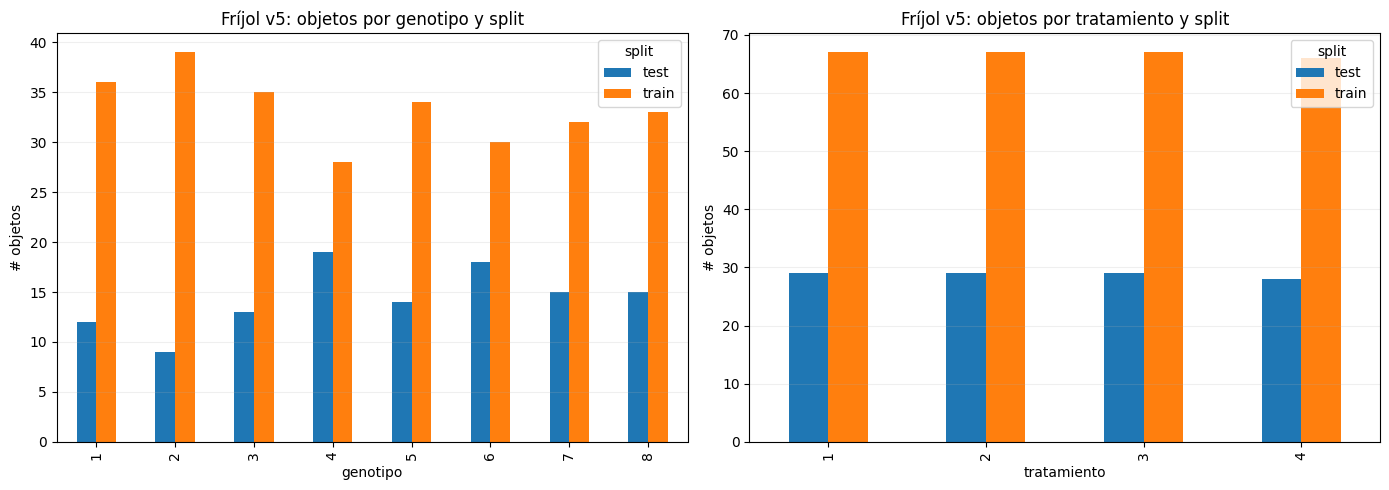

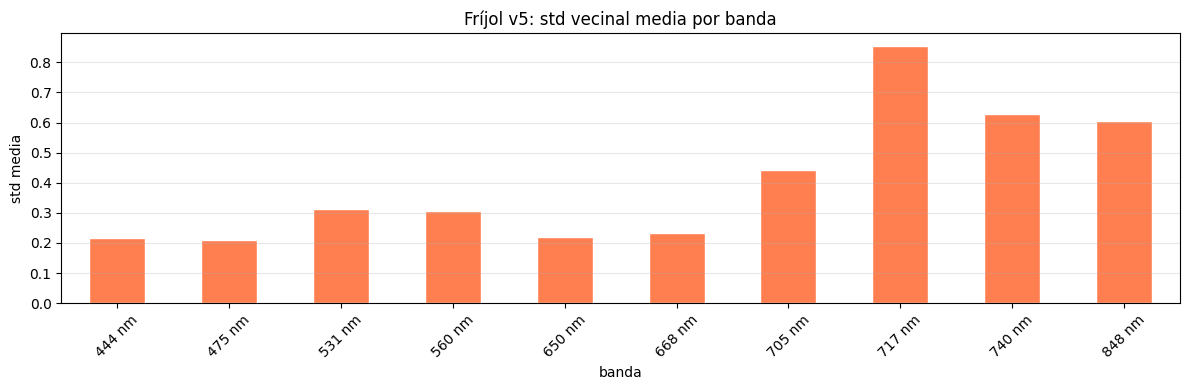

In [27]:
if qa_frijol is not None:
    df_f = pd.concat([qa_frijol["train"], qa_frijol["test"]], ignore_index=True)
    band_cols = qa_frijol["band_cols"]
    mean_cols = qa_frijol["mean_cols"]
    std_cols  = qa_frijol["std_cols"]

    # Distribución de tratamiento y genotipo por split
    geno_split = df_f.groupby(["split", "genotipo"])["object_id"].nunique().unstack(fill_value=0)
    trt_split  = df_f.groupby(["split", "tratamiento"])["object_id"].nunique().unstack(fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    geno_split.T.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Fríjol v5: objetos por genotipo y split")
    axes[0].set_xlabel("genotipo")
    axes[0].set_ylabel("# objetos")
    axes[0].grid(axis="y", alpha=0.2)

    trt_split.T.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Fríjol v5: objetos por tratamiento y split")
    axes[1].set_xlabel("tratamiento")
    axes[1].set_ylabel("# objetos")
    axes[1].grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Distribución de std media por banda (indica variabilidad textural capturada)
    std_medias = df_f[std_cols].mean().rename("mean_std")
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    std_medias.plot(kind="bar", ax=ax2, color="coral", edgecolor="white")
    ax2.set_title("Fríjol v5: std vecinal media por banda")
    ax2.set_xlabel("banda")
    ax2.set_ylabel("std media")
    ax2.set_xticklabels([b.replace("std_", "") + " nm" for b in std_cols], rotation=45)
    ax2.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("QA no disponible: ejecuta primero el pipeline de fríjol.")

In [28]:
qa_maiz = verificar_dataset_v5(
    cultivo="maiz",
    expected_ratio=float(TRAIN_RATIO),
    ratio_tolerance=0.12,
)


=== QA v5 — MAIZ ===
✅ train: esquema de 36 columnas correcto
✅ test: esquema de 36 columnas correcto
✅ Sin fuga entre train y test
✅ Columna split consistente con el manifest
✅ Sin nulos en columnas requeridas
✅ int_* en [0, 255]
✅ mean_* en [0, 255]
✅ std_* ≥ 0

Split por objeto: train=401, test=172, ratio_train=0.6998
✅ Ratio de split dentro de tolerancia

Resumen por split:
         filas  objetos_unicos  genotipos_unicos  tratamientos_unicos
split                                                                
test   1142339             172                10                    4
train  2718828             401                10                    4

Estadísticas de mean_* (muestra de 3 bandas):
           mean_444      mean_475      mean_531
count  3.861167e+06  3.861167e+06  3.861167e+06
mean   2.042125e+00  2.577333e+00  5.123188e+00
std    1.696208e+00  1.414487e+00  1.982909e+00
min    0.000000e+00  7.730000e-02  6.298000e-01
25%    8.814000e-01  1.556100e+00  3.676400e+00
50%

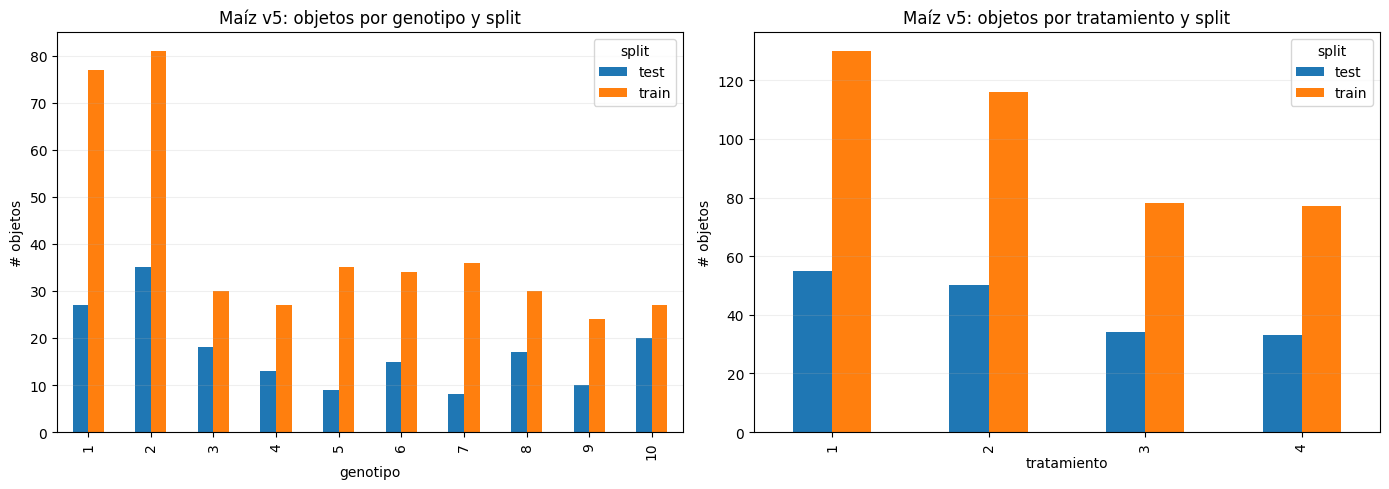

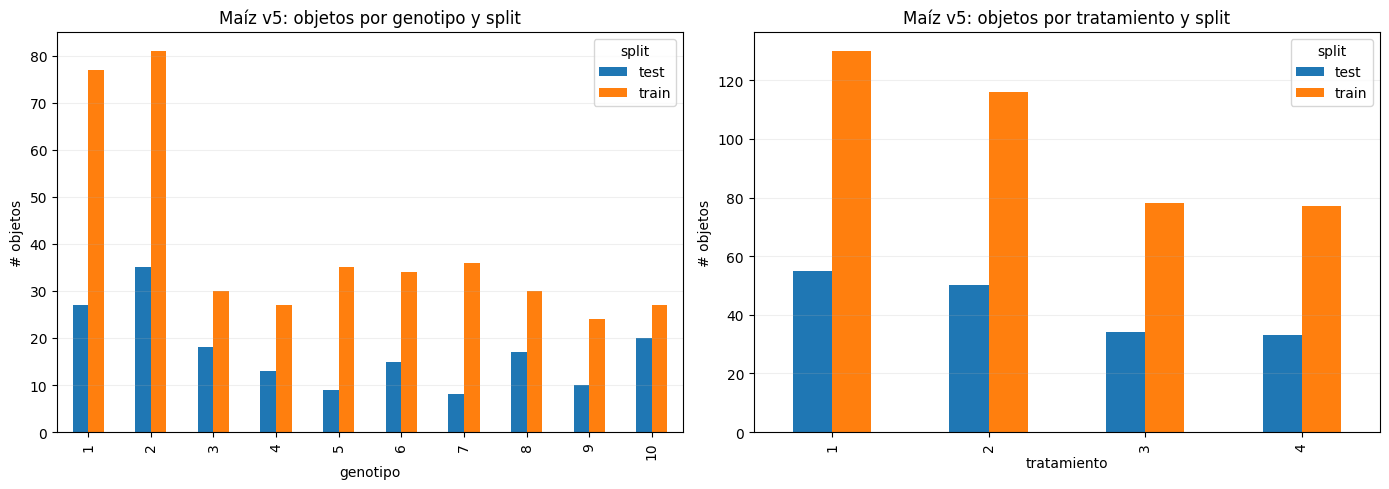

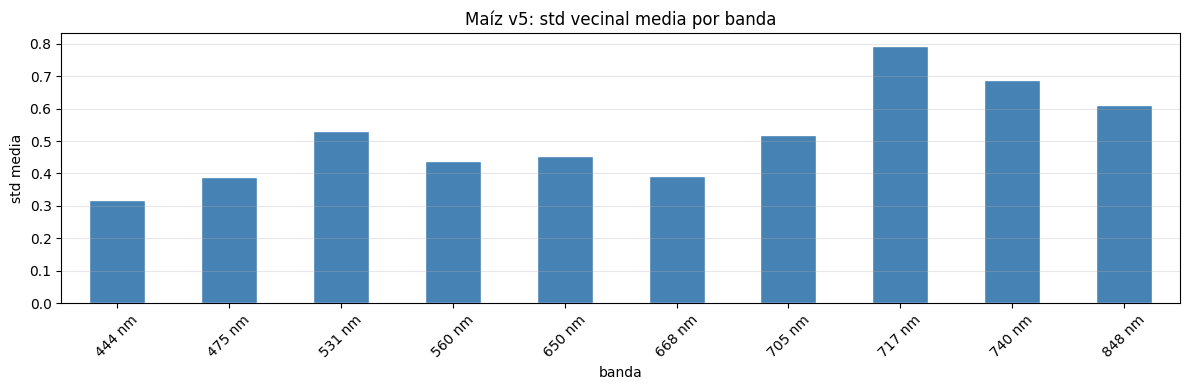

In [37]:
if qa_maiz is not None:
    df_m = pd.concat([qa_maiz["train"], qa_maiz["test"]], ignore_index=True)
    std_cols_m = qa_maiz["std_cols"]

    geno_split_m = df_m.groupby(["split", "genotipo"])["object_id"].nunique().unstack(fill_value=0)
    trt_split_m  = df_m.groupby(["split", "tratamiento"])["object_id"].nunique().unstack(fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    geno_split_m.T.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Maíz v5: objetos por genotipo y split")
    axes[0].set_xlabel("genotipo")
    axes[0].set_ylabel("# objetos")
    axes[0].grid(axis="y", alpha=0.2)

    trt_split_m.T.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Maíz v5: objetos por tratamiento y split")
    axes[1].set_xlabel("tratamiento")
    axes[1].set_ylabel("# objetos")
    axes[1].grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

    std_medias_m = df_m[std_cols_m].mean().rename("mean_std")
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    std_medias_m.plot(kind="bar", ax=ax2, color="steelblue", edgecolor="white")
    ax2.set_title("Maíz v5: std vecinal media por banda")
    ax2.set_xlabel("banda")
    ax2.set_ylabel("std media")
    ax2.set_xticklabels([b.replace("std_", "") + " nm" for b in std_cols_m], rotation=45)
    ax2.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("QA no disponible: ejecuta primero el pipeline de maíz.")